In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.parser import parse as parse_date

Anomalies

In [13]:
# read in labels csv 
labels_df = pd.read_csv("C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\ESA-Mission1_subset\\labels.csv",  parse_dates=["StartTime", "EndTime"], date_parser=lambda x: parse_date(x, ignoretz=True))

# read in anomaly_types csv 
anomaly_types_df = pd.read_csv("C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\ESA-Mission1_subset\\anomaly_types.csv")


C:\Users\angus\AppData\Local\Temp\ipykernel_23316\2045946753.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  labels_df = pd.read_csv("C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\ESA-Mission1_subset\\labels.csv",  parse_dates=["StartTime", "EndTime"], date_parser=lambda x: parse_date(x, ignoretz=True))


In [3]:
print(labels_df.head())

     ID     Channel               StartTime                 EndTime
0  id_1  channel_41 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
1  id_1  channel_42 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
2  id_1  channel_43 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
3  id_1  channel_44 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
4  id_1  channel_45 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146


In [14]:
# subset 41-46
subset_channels = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

subset_labels_df = labels_df[labels_df['Channel'].isin(subset_channels)]

print(subset_labels_df.head())

     ID     Channel               StartTime                 EndTime
0  id_1  channel_41 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
1  id_1  channel_42 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
2  id_1  channel_43 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
3  id_1  channel_44 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146
4  id_1  channel_45 2004-12-02 03:07:17.646 2004-12-08 23:35:55.146


In [15]:
for channel in subset_channels:
    channel_df = subset_labels_df[subset_labels_df['Channel'] == channel]
    unique_events = channel_df['ID'].unique()
    print(f"Channel: {channel}, Number of anomalies: {len(unique_events)}")

Channel: channel_41, Number of anomalies: 118
Channel: channel_42, Number of anomalies: 116
Channel: channel_43, Number of anomalies: 116
Channel: channel_44, Number of anomalies: 115
Channel: channel_45, Number of anomalies: 117
Channel: channel_46, Number of anomalies: 114


3 month processed data

In [16]:
# read csv

# path to desired processed dataset
three_month_train_path = "C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\preprocessed_subset\\multivariate\\ESA-Mission1-semi-supervised\\3_months.train.csv"
ten_month_train_path = "C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\preprocessed_subset\\multivariate\\ESA-Mission1-semi-supervised\\10_months.train.csv"
eighty_four_month_test_path = "C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\preprocessed_subset\\multivariate\\ESA-Mission1-semi-supervised\\84_months.test.csv"

df = pd.read_csv(eighty_four_month_test_path)

In [17]:
print(df.head())

             timestamp  channel_41  channel_42  channel_43  channel_44  \
0  2007-01-01 00:00:00    0.812578    0.787950    0.763988    0.799177   
1  2007-01-01 00:00:30    0.812578    0.787950    0.763988    0.799177   
2  2007-01-01 00:01:00    0.811009    0.793574    0.768734    0.799177   
3  2007-01-01 00:01:30    0.813363    0.795983    0.766361    0.803115   
4  2007-01-01 00:02:00    0.814932    0.789557    0.766361    0.800752   

   channel_45  channel_46  is_anomaly_channel_41  is_anomaly_channel_42  \
0    0.820247    0.760228                      0                      0   
1    0.820247    0.760228                      0                      0   
2    0.818551    0.763607                      0                      0   
3    0.820247    0.760228                      0                      0   
4    0.819398    0.761918                      0                      0   

   is_anomaly_channel_43  is_anomaly_channel_44  is_anomaly_channel_45  \
0                      0      

In [18]:
# subset 41-46
anomaly_subset = ['is_anomaly_' + channel for channel in subset_channels]


cols_to_keep = [
    c for c in df.columns
    if c in subset_channels or c in anomaly_subset or c == 'timestamp'
]

subset_df_temp = df[cols_to_keep]

subset_df = subset_df_temp.copy()

subset_df['timestamp'] = pd.to_datetime(subset_df['timestamp'])


print(subset_df.head())

KeyboardInterrupt: 

In [ ]:
# printing df columns
for col in subset_df.columns:
    print(col)

timestamp
channel_41
channel_42
channel_43
channel_44
channel_45
channel_46
is_anomaly_channel_41
is_anomaly_channel_42
is_anomaly_channel_43
is_anomaly_channel_44
is_anomaly_channel_45
is_anomaly_channel_46


In [ ]:
print(len(subset_df))

878401


In [19]:
# finding timestamp range
subset_df['timestamp'] = pd.to_datetime(subset_df['timestamp'])

start_time = subset_df['timestamp'].min()
end_time = subset_df['timestamp'].max()

print("Start:", start_time)
print("End:", end_time)


Start: 2007-01-01 00:00:00
End: 2014-01-01 00:00:00


In [20]:
# finding num anomalies in this timeperiod using labels

labels_in_timeperiod = subset_labels_df[(subset_labels_df['StartTime'] <= end_time) & (subset_labels_df['EndTime'] >= start_time)]

#print(labels_in_timeperiod)

unique_events = labels_in_timeperiod['ID'].unique()
print(f"Number of unique anomalies in time period: {len(unique_events)}")

for channel in subset_channels:
    channel_df = labels_in_timeperiod[labels_in_timeperiod['Channel'] == channel]
    unique_events_per_channel = channel_df['ID'].unique()
    print(f"Channel: {channel}, Number of unique anomalies in time period: {len(unique_events_per_channel)}")

Number of unique anomalies in time period: 65
Channel: channel_41, Number of unique anomalies in time period: 65
Channel: channel_42, Number of unique anomalies in time period: 63
Channel: channel_43, Number of unique anomalies in time period: 64
Channel: channel_44, Number of unique anomalies in time period: 63
Channel: channel_45, Number of unique anomalies in time period: 64
Channel: channel_46, Number of unique anomalies in time period: 62


Anomaly IDs in time period: ['id_14', 'id_15', 'id_18', 'id_24', 'id_26', 'id_27', 'id_28', 'id_29', 'id_31', 'id_32', 'id_33', 'id_34', 'id_40', 'id_42', 'id_44', 'id_47', 'id_48', 'id_49', 'id_50', 'id_51', 'id_55', 'id_116', 'id_117', 'id_118', 'id_121', 'id_122', 'id_123', 'id_124', 'id_125', 'id_128', 'id_129', 'id_130', 'id_132', 'id_133', 'id_134', 'id_136', 'id_138', 'id_139', 'id_140', 'id_142', 'id_145', 'id_147', 'id_149', 'id_150', 'id_153', 'id_154', 'id_155', 'id_157', 'id_159', 'id_160', 'id_164', 'id_165', 'id_166', 'id_169', 'id_172', 'id_174', 'id_175', 'id_176', 'id_177', 'id_180', 'id_182', 'id_183', 'id_184', 'id_186', 'id_187']
Plotting anomaly ID: id_118
Anomaly ID: id_118, Start: 2007-05-22 04:30:06.120000, End: 2007-05-22 06:30:06.120000, Length: 0 days 02:00:00


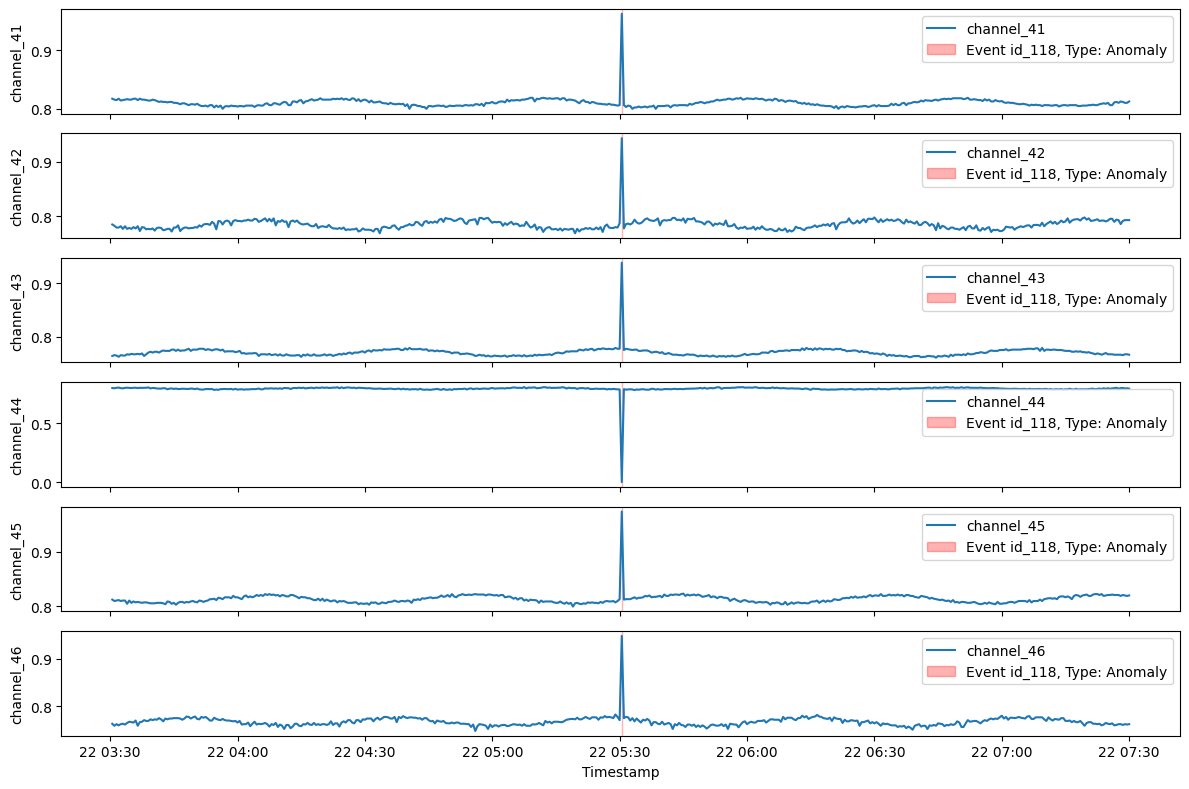

In [21]:
anomalies_ids_in_period = labels_in_timeperiod['ID'].unique().tolist()
print("Anomaly IDs in time period:", anomalies_ids_in_period)

def plotting_anomaly(subset_df, anomaly_subset, subset_channels, labels_in_timeperiod, target_anomaly_id = anomalies_ids_in_period[0]):

    # find anomalies with id in time period and find the corresponding time range
    target_anomaly_df = labels_in_timeperiod[labels_in_timeperiod['ID'] == target_anomaly_id]
    
    
    # find earliest start date and latest end date for this anomaly id
    anomaly_start_time = target_anomaly_df['StartTime'].min() - pd.Timedelta(hours=1)
    anomaly_end_time = target_anomaly_df['EndTime'].max() + pd.Timedelta(hours=1)

    anomaly_length = anomaly_end_time - anomaly_start_time

    print(f"Anomaly ID: {target_anomaly_id}, Start: {anomaly_start_time}, End: {anomaly_end_time}, Length: {anomaly_length}")

    anomaly_plot_start = anomaly_start_time - anomaly_length/2
    anomaly_plot_end = anomaly_end_time + anomaly_length/2


    # filter to the first anomaly day
    anomaly_df = subset_df[
        (subset_df['timestamp'] >= anomaly_plot_start) &
        (subset_df['timestamp'] <  anomaly_plot_end)
    ].copy()

    #for channel in anomaly_subset:
    #    print(channel, anomaly_df[channel].unique())

    anomaly_labels_df = labels_in_timeperiod[
        (labels_in_timeperiod['StartTime'] >= anomaly_plot_start) &
        (labels_in_timeperiod['EndTime'] <  anomaly_plot_end)
    ].copy()

    # create figure
    fig, axs = plt.subplots(
        len(subset_channels),
        1,
        figsize=(12, 8),
        sharex=True
    )

    # plotting anomaly in subset of channels
    for i, channel in enumerate(subset_channels):
        axs[i].plot(
            anomaly_df['timestamp'],
            anomaly_df[channel],
            label=channel
        )
        axs[i].set_ylabel(channel)
        axs[i].legend(loc='upper right')

        # shading 
        # non-zero mask for THIS column
        mask = anomaly_df['is_anomaly_'+ channel] != 0

        # find contiguous non-zero regions
        groups = (mask != mask.shift()).cumsum()

        # finding anomaly type for labelling on plot
        anomaly_type = anomaly_types_df[anomaly_types_df['ID'] == target_anomaly_id]['Category'].values[0]

        # ensures label only printed once for each anomaly region
        first = True

        for _, g in anomaly_df[mask].groupby(groups):
            axs[i].axvspan(
                g['timestamp'].iloc[0],
                g['timestamp'].iloc[-1],
                label=f'Event {target_anomaly_id}, Type: {anomaly_type}' if first else None,
                color='red',
                alpha=0.3
            )
            first = False

        axs[i].legend(loc='upper right')


        # shading anomaly regions based on labels data
        """for _, row in anomaly_labels_df.iterrows():

            start_time = row['StartTime']
            end_time = row['EndTime']
            channel_label = row['Channel']
            if channel_label == channel:
                axs[i].axvspan(
                    start_time,
                    end_time,
                    color='red',
                    alpha=0.3,
                    label = f'Anomaly {target_anomaly_id}: {anomaly_type}'
                )
                axs[i].legend(loc='upper right')"""

    axs[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

# plot random anomaly
random_anomaly = np.random.choice(anomalies_ids_in_period)
print("Plotting anomaly ID:", random_anomaly)
plotting_anomaly(subset_df, anomaly_subset, subset_channels, labels_in_timeperiod, target_anomaly_id = random_anomaly)

analyis of anomaly distribution

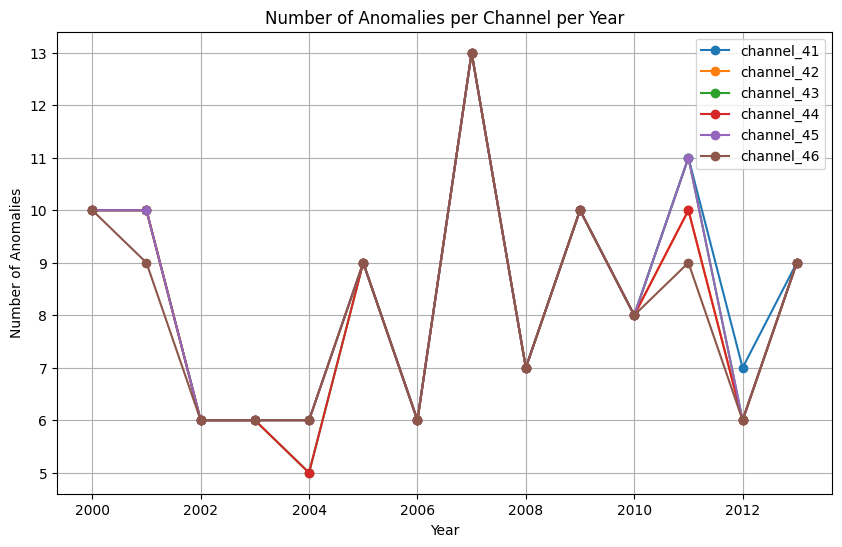

In [22]:
# find num anomalies per channel per year
subset_labels_df['Year'] = subset_labels_df['StartTime'].dt.year

anomalies_per_channel_per_year = subset_labels_df.groupby(['Channel', 'Year'])['ID'].nunique().reset_index()

anomalies_per_channel_per_year.rename(columns={'ID': 'Num_Anomalies'}, inplace=True)

# channel on x axis, year on y axis, num anomalies as values

anomalies_per_channel_per_year = anomalies_per_channel_per_year.pivot(
    index='Year',
    columns='Channel',
    values='Num_Anomalies'
).fillna(0)

# plot lineplot for each channel
plt.figure(figsize=(10, 6))
for channel in subset_channels:
    plt.plot(
        anomalies_per_channel_per_year.index,
        anomalies_per_channel_per_year[channel],
        marker='o',
        label=channel
    )
plt.title("Number of Anomalies per Channel per Year")
plt.xlabel("Year")
plt.ylabel("Number of Anomalies")
plt.legend()
plt.grid()
plt.show()


In [23]:
eighty_four_month_train_path = "C:\\Users\\angus\\OneDrive - University of Bristol\\mdm3_satellite\\satelite\\ESA-ADB-mdm\\data\\preprocessed_subset\\multivariate\\ESA-Mission1-semi-supervised\\84_months.test.csv"

df = pd.read_csv(eighty_four_month_train_path)

finding percentage of annotated points

In [24]:
# find number of anomalous points in this dataset for channels 41-46
# subset 41-46
subset_channels = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
anomaly_subset = ['is_anomaly_' + channel for channel in subset_channels]

# count number of anomalous points per channel
total_anomalous_points = 0
num_points = 0
for channel in anomaly_subset:
    # find the number of points where the value in the channel is non zero
    num_anomalous_points = (df[channel] != 0).sum()
    print(f"Channel: {channel}, Number of anomalous points: {num_anomalous_points}")
    total_anomalous_points += num_anomalous_points
    num_points += len(df[channel])

print(f"Total number of anomalous points across channels 41-46: {total_anomalous_points}")
print(f"Total number of points across channels 41-46: {num_points}")
anomaly_percentage = (total_anomalous_points / num_points) * 100
print(f"Percentage of anomalous points across channels 41-46: {anomaly_percentage:.6f}%")


Channel: is_anomaly_channel_41, Number of anomalous points: 133142
Channel: is_anomaly_channel_42, Number of anomalous points: 133200
Channel: is_anomaly_channel_43, Number of anomalous points: 133142
Channel: is_anomaly_channel_44, Number of anomalous points: 133120
Channel: is_anomaly_channel_45, Number of anomalous points: 133139
Channel: is_anomaly_channel_46, Number of anomalous points: 133105
Total number of anomalous points across channels 41-46: 798848
Total number of points across channels 41-46: 44184966
Percentage of anomalous points across channels 41-46: 1.807963%


In [51]:
pred_path = r"\Users\angus\OneDrive - University of Bristol\mdm3_satellite\satelite\Anomaly-Transformer-ESA-ADB\results\test_1\pred.csv"
df_pred = pd.read_csv(pred_path)

In [26]:
# find number of anomalous points in this dataset for channels 41-46
# subset 41-46
subset_channels = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
anomaly_subset = ['is_anomaly_' + channel for channel in subset_channels]

# count number of anomalous points per channel
total_anomalous_points = 0
num_points = 0
for channel in subset_channels:
    # find the number of points where the value in the channel is non zero
    num_anomalous_points = (df_pred[channel] != 0).sum()
    print(f"Channel: {channel}, Number of anomalous points: {num_anomalous_points}")
    total_anomalous_points += num_anomalous_points
    num_points += len(df_pred[channel])

print(f"Total number of anomalous points across channels 41-46: {total_anomalous_points}")
print(f"Total number of points across channels 41-46: {num_points}")
anomaly_percentage = (total_anomalous_points / num_points) * 100
print(f"Percentage of anomalous points across channels 41-46: {anomaly_percentage:.6f}%")




Channel: channel_41, Number of anomalous points: 73355
Channel: channel_42, Number of anomalous points: 75187
Channel: channel_43, Number of anomalous points: 77650
Channel: channel_44, Number of anomalous points: 73675
Channel: channel_45, Number of anomalous points: 74884
Channel: channel_46, Number of anomalous points: 73254
Total number of anomalous points across channels 41-46: 448005
Total number of points across channels 41-46: 44184600
Percentage of anomalous points across channels 41-46: 1.013939%


Plotting anomaly ID: id_150
Anomaly ID: id_150, Start: 2010-10-26 16:25:39.846000, End: 2010-10-26 18:25:44.934000, Length: 0 days 02:00:05.088000


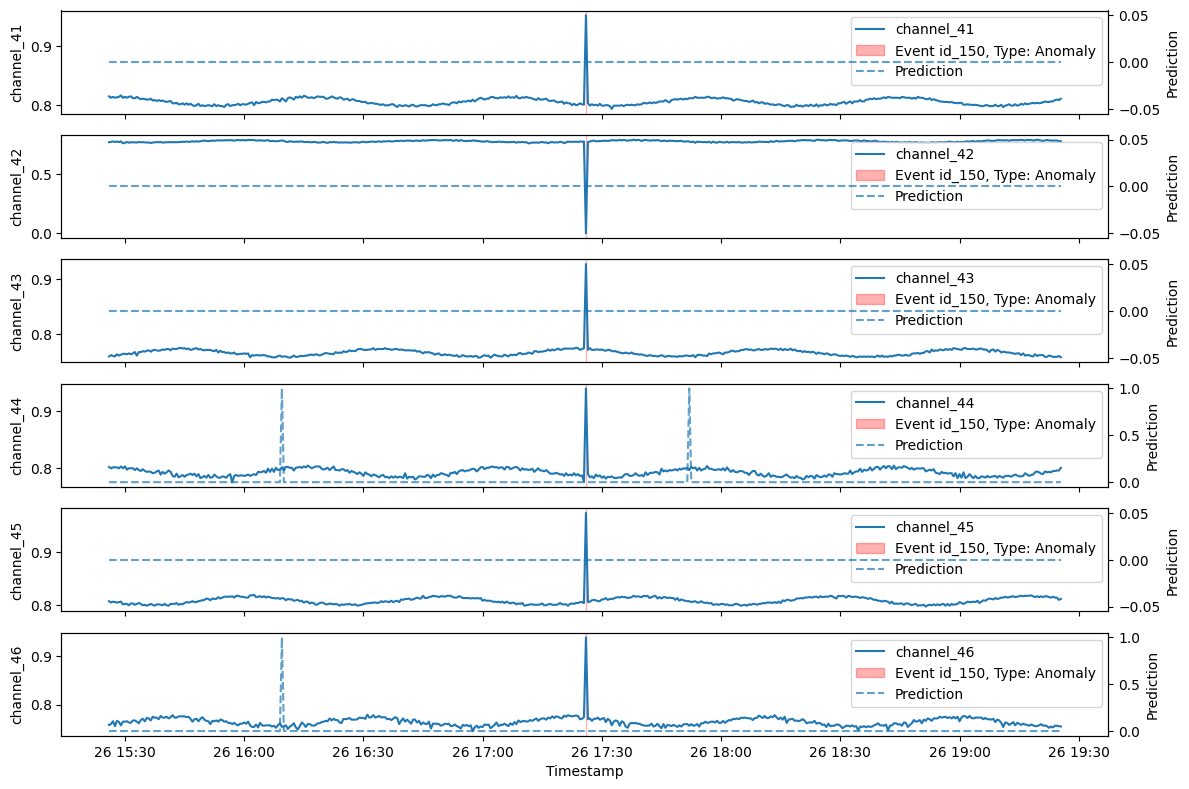

In [57]:
def plotting_pred(
    subset_df,
    pred_df,
    anomaly_subset,
    subset_channels,
    labels_in_timeperiod,
    target_anomaly_id
):

    # find anomalies with id in time period
    target_anomaly_df = labels_in_timeperiod[
        labels_in_timeperiod['ID'] == target_anomaly_id
    ]

    anomaly_start_time = target_anomaly_df['StartTime'].min() - pd.Timedelta(hours=1)
    anomaly_end_time   = target_anomaly_df['EndTime'].max() + pd.Timedelta(hours=1)

    anomaly_length = anomaly_end_time - anomaly_start_time

    print(
        f"Anomaly ID: {target_anomaly_id}, "
        f"Start: {anomaly_start_time}, "
        f"End: {anomaly_end_time}, "
        f"Length: {anomaly_length}"
    )

    anomaly_plot_start = anomaly_start_time - anomaly_length / 2
    anomaly_plot_end   = anomaly_end_time   + anomaly_length / 2

    # filter signal data
    anomaly_df = subset_df[
        (subset_df['timestamp'] >= anomaly_plot_start) &
        (subset_df['timestamp'] <  anomaly_plot_end)
    ].copy()

    pred_df['timestamp'] = pd.to_datetime(pred_df['timestamp'])

    # filter prediction data
    pred_anomaly_df = pred_df[
        (pred_df['timestamp'] >= anomaly_plot_start) &
        (pred_df['timestamp'] <  anomaly_plot_end)
    ].copy()

    # create figure
    fig, axs = plt.subplots(
        len(subset_channels),
        1,
        figsize=(12, 8),
        sharex=True
    )

    anomaly_type = anomaly_types_df.loc[
        anomaly_types_df['ID'] == target_anomaly_id, 'Category'
    ].values[0]

    for i, channel in enumerate(subset_channels):

        # ---- raw signal ----
        axs[i].plot(
            anomaly_df['timestamp'],
            anomaly_df[channel],
            label=channel
        )
        axs[i].set_ylabel(channel)

        # ---- prediction (second y-axis) ----
        ax_pred = axs[i].twinx()
        ax_pred.plot(
            pred_anomaly_df['timestamp'],
            pred_anomaly_df[f'{channel}'],
            linestyle='--',
            alpha=0.7,
            label='Prediction'
        )
        ax_pred.set_ylabel("Prediction")

        # ---- anomaly shading from labels ----
        mask = anomaly_df[f'is_anomaly_{channel}'] != 0
        groups = (mask != mask.shift()).cumsum()

        first = True
        for _, g in anomaly_df[mask].groupby(groups):
            axs[i].axvspan(
                g['timestamp'].iloc[0],
                g['timestamp'].iloc[-1],
                color='red',
                alpha=0.3,
                label=f'Event {target_anomaly_id}, Type: {anomaly_type}' if first else None
            )
            first = False

        # ---- legends (merge both axes) ----
        lines1, labels1 = axs[i].get_legend_handles_labels()
        lines2, labels2 = ax_pred.get_legend_handles_labels()
        axs[i].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    axs[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    plt.show()


random_anomaly = np.random.choice(anomalies_ids_in_period)
print("Plotting anomaly ID:", random_anomaly)

plotting_pred(
    subset_df,
    df_pred,
    anomaly_subset,
    subset_channels,
    labels_in_timeperiod,
    target_anomaly_id=random_anomaly
)